# Klasifikasi Citra Botol Parfum dengan HOG, PCA, dan SVM

Tugas Individu, EA234503 Visi Komputer
*Machine Learning in My Daily Life: Personal Reflection and Creative Application in Image Classification*

## Deskripsi Masalah

Saya punya tiga botol parfum di kamar, dan ketiganya kebetulan berbeda warna kemasan. Itu yang membuat saya memilih tema ini: perbedaan warna dan bentuk antar botol terlihat jelas ke mata, tapi saya penasaran apakah metode klasifikasi citra tradisional bisa menangkap perbedaan itu tanpa deep learning.

Masalah di notebook ini adalah klasifikasi citra multi-kelas dengan tiga label: `Perfume-1`, `Perfume-2`, dan `Perfume-3`, masing-masing mewakili satu botol parfum. Pipeline-nya murni machine learning klasik: ekstraksi fitur dengan HOG (Histogram of Oriented Gradients), reduksi dimensi dengan PCA, dan klasifikasi dengan SVM. Tidak ada jaringan saraf di sini, jadi tantangan utamanya ada pada seberapa jauh fitur buatan tangan bisa membedakan bentuk, tekstur, dan siluet tiap botol.

## Deskripsi Dataset

Saya ambil semua foto sendiri pakai kamera ponsel Xiaomi M2101K7BNY, pada 14 dan 15 September 2026. Total 46 citra, terbagi ke tiga kelas botol parfum. Setiap file tercatat lengkap di `dataset_metadata.csv`: nama kamera, waktu pengambilan, exposure time, ISO, dan resolusi. Keasliannya bisa dicek langsung dari metadata EXIF itu, tanpa perlu bukti tambahan.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

DATASET_DIR = "dataset"
METADATA_CSV = "dataset_metadata.csv"

meta = pd.read_csv(METADATA_CSV)
meta.head()

,class,filename,width,height,camera_make,camera_model,date_taken,focal_length_mm,exposure_time_s,f_number,iso,flash,has_gps
0,Perfume-1,IMG_20260915_182148.jpg,3472,3472,Xiaomi,M2101K7BNY,2026:09:15 18:21:48,4.74,0.050002,1.79,889,16,False
1,Perfume-1,IMG_20260915_182152.jpg,3472,3472,Xiaomi,M2101K7BNY,2026:09:15 18:21:52,4.74,0.050002,1.79,896,16,False
2,Perfume-1,IMG_20260915_182155.jpg,3472,3472,Xiaomi,M2101K7BNY,2026:09:15 18:21:55,4.74,0.050002,1.79,809,16,False
3,Perfume-1,IMG_20260915_182200.jpg,3472,3472,Xiaomi,M2101K7BNY,2026:09:15 18:22:00,4.74,0.050002,1.79,836,16,False
4,Perfume-1,IMG_20260915_182204.jpg,3472,3472,Xiaomi,M2101K7BNY,2026:09:15 18:22:04,4.74,0.050002,1.79,757,16,False


In [2]:
class_counts = meta["class"].value_counts().sort_index()
class_counts

class
Perfume-1    16
Perfume-2    15
Perfume-3    15
Name: count, dtype: int64

In [3]:
meta.groupby("class")[["width", "height", "exposure_time_s", "iso"]].describe().T

class                    Perfume-1    Perfume-2    Perfume-3
width           count    16.000000    15.000000    15.000000
                mean   3472.000000  3472.000000  3472.000000
                std       0.000000     0.000000     0.000000
                min    3472.000000  3472.000000  3472.000000
                25%    3472.000000  3472.000000  3472.000000
                50%    3472.000000  3472.000000  3472.000000
                75%    3472.000000  3472.000000  3472.000000
                max    3472.000000  3472.000000  3472.000000
height          count    16.000000    15.000000    15.000000
                mean   3472.000000  3472.000000  3779.200000
                std       0.000000     0.000000   527.313840
                min    3472.000000  3472.000000  3472.000000
                25%    3472.000000  3472.000000  3472.000000
                50%    3472.000000  3472.000000  3472.000000
                75%    3472.000000  3472.000000  4048.000000
                max    3472.000000  3472.000000  4624.000000
exposure_time_s count    16.000000    15.000000    15.000000
                mean      0.048127     0.048002     0.038666
                std       0.007501     0.006763     0.017269
                min       0.040000     0.040000     0.019996
                25%       0.040000     0.040000     0.019996
                50%       0.050002     0.050002     0.040000
                75%       0.050002     0.050002     0.055003
                max       0.060004     0.060004     0.060004
iso             count    16.000000    15.000000    15.000000
                mean    996.500000  1042.533333  1101.466667
                std     734.863253   495.513279  1214.512769
                min     540.000000   543.000000    58.000000
                25%     603.750000   632.000000    94.500000
                50%     783.000000   683.000000   638.000000
                75%     890.750000  1458.000000  2170.000000
                max    3446.000000  1908.000000  3286.000000

## Analisis Eksploratif Dataset

Ketiga botol ini beda warna, jadi masuk akal untuk melihat dulu seberapa besar bedanya sebelum masuk ke ekstraksi fitur. HOG sendiri bekerja di ranah gradien intensitas, bukan warna. Bagian ini jadi bahan diskusi nanti: apakah bentuk saja cukup untuk memisahkan ketiga kelas, atau warna justru sinyal yang lebih kuat yang tidak tertangkap oleh HOG.

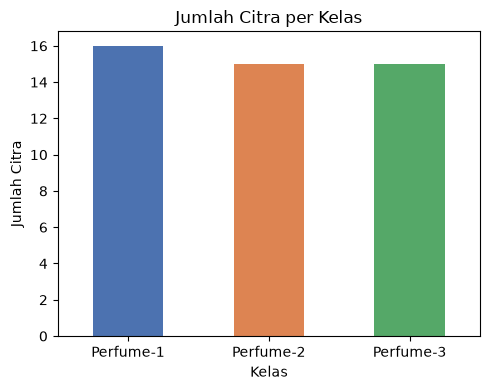

In [4]:
plt.figure(figsize=(5, 4))
class_counts.plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Jumlah Citra per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Citra")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
def load_image(cls, filename, size=None):
    path = os.path.join(DATASET_DIR, cls, filename)
    img = Image.open(path).convert("RGB")
    if size is not None:
        img = img.resize(size)
    return img

def mean_rgb(cls, filename):
    img = load_image(cls, filename, size=(256, 256))
    arr = np.asarray(img).reshape(-1, 3)
    return arr.mean(axis=0)

rows = []
for _, r in meta.iterrows():
    r_mean, g_mean, b_mean = mean_rgb(r["class"], r["filename"])
    rows.append({"class": r["class"], "R": r_mean, "G": g_mean, "B": b_mean})

color_df = pd.DataFrame(rows)
color_summary = color_df.groupby("class")[["R", "G", "B"]].mean()
color_summary

,R,G,B
class,,,
Perfume-1,134.709262,116.434629,106.075617
Perfume-2,122.678520,117.884438,104.749661
Perfume-3,127.345536,125.377893,121.961551


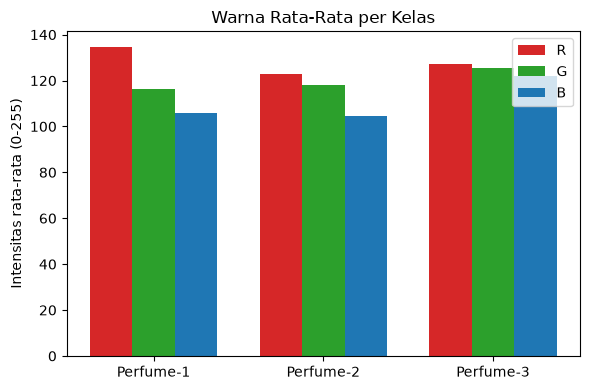

In [6]:
x = np.arange(len(color_summary))
width = 0.25
plt.figure(figsize=(6, 4))
for i, channel in enumerate(["R", "G", "B"]):
    plt.bar(x + i * width, color_summary[channel], width, label=channel,
            color=["#d62728", "#2ca02c", "#1f77b4"][i])
plt.xticks(x + width, color_summary.index)
plt.ylabel("Intensitas rata-rata (0-255)")
plt.title("Warna Rata-Rata per Kelas")
plt.legend()
plt.tight_layout()
plt.show()

## Visualisasi Contoh Citra

Berikut beberapa contoh citra dari tiap kelas, langsung dari file asli tanpa pre-processing.

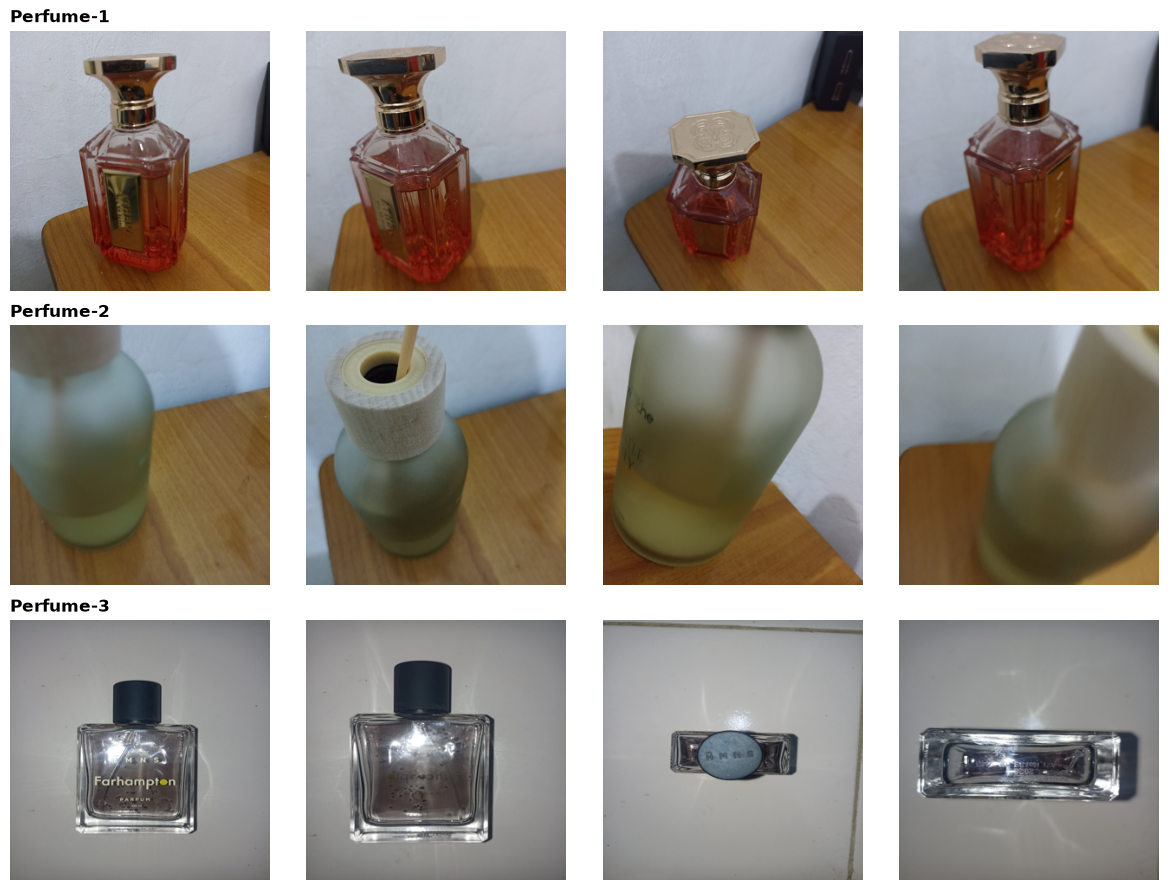

In [7]:
classes = sorted(meta["class"].unique())
n_samples = 4

fig, axes = plt.subplots(len(classes), n_samples, figsize=(3 * n_samples, 3 * len(classes)))
for row, cls in enumerate(classes):
    files = meta[meta["class"] == cls]["filename"].values[:n_samples]
    for col, fname in enumerate(files):
        img = load_image(cls, fname, size=(300, 300))
        ax = axes[row, col]
        ax.imshow(img)
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(cls)
    axes[row, 0].set_title(cls, loc="left", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## Pre-processing

Foto-foto ini punya resolusi besar dan tidak seragam: sebagian 3472x3472, sebagian lain 3472x4624 (kelas `Perfume-3` sempat difoto dengan orientasi berbeda). Sebelum ekstraksi fitur, semua citra saya resize ke ukuran tetap dan ubah ke grayscale, karena HOG bekerja pada gradien intensitas, bukan warna.

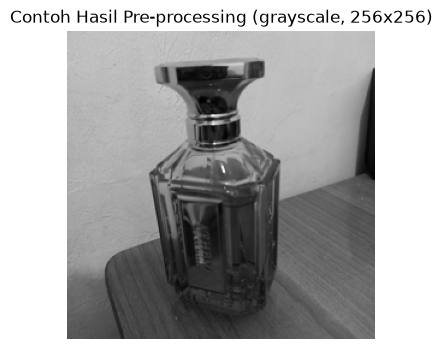

In [8]:
IMG_SIZE = (256, 256)

def preprocess(cls, filename):
    img = load_image(cls, filename, size=IMG_SIZE)
    gray = np.asarray(img.convert("L"), dtype=np.float64) / 255.0
    return gray

sample_gray = preprocess(meta.iloc[0]["class"], meta.iloc[0]["filename"])
plt.figure(figsize=(4, 4))
plt.imshow(sample_gray, cmap="gray")
plt.title("Contoh Hasil Pre-processing (grayscale, 256x256)")
plt.axis("off")
plt.show()

## Feature Extraction: HOG

HOG meringkas sebuah citra menjadi histogram arah gradien intensitas di tiap sel kecil (cell), lalu menormalkannya per blok. Hasilnya adalah deskriptor yang menangkap kontur dan bentuk objek, cocok untuk membedakan siluet botol, bentuk tutup, dan garis label, tapi buta terhadap warna.

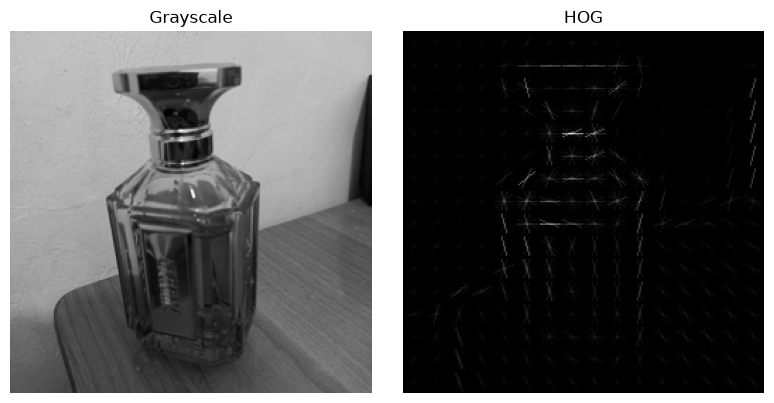

Panjang vektor fitur HOG per citra: 8100


In [9]:
from skimage.feature import hog

HOG_PARAMS = dict(orientations=9, pixels_per_cell=(16, 16), cells_per_block=(2, 2), block_norm="L2-Hys")

def extract_hog(gray_img, visualize=False):
    return hog(gray_img, visualize=visualize, **HOG_PARAMS)

# Visualisasi HOG pada satu contoh citra
features_vis, hog_image = extract_hog(sample_gray, visualize=True)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sample_gray, cmap="gray")
axes[0].set_title("Grayscale")
axes[0].axis("off")
axes[1].imshow(hog_image, cmap="gray")
axes[1].set_title("HOG")
axes[1].axis("off")
plt.tight_layout()
plt.show()

print("Panjang vektor fitur HOG per citra:", features_vis.shape[0])

Berikut hasil HOG untuk tiga citra dari masing-masing kelas, supaya kelihatan apakah pola gradiennya konsisten dalam satu kelas atau malah bervariasi.

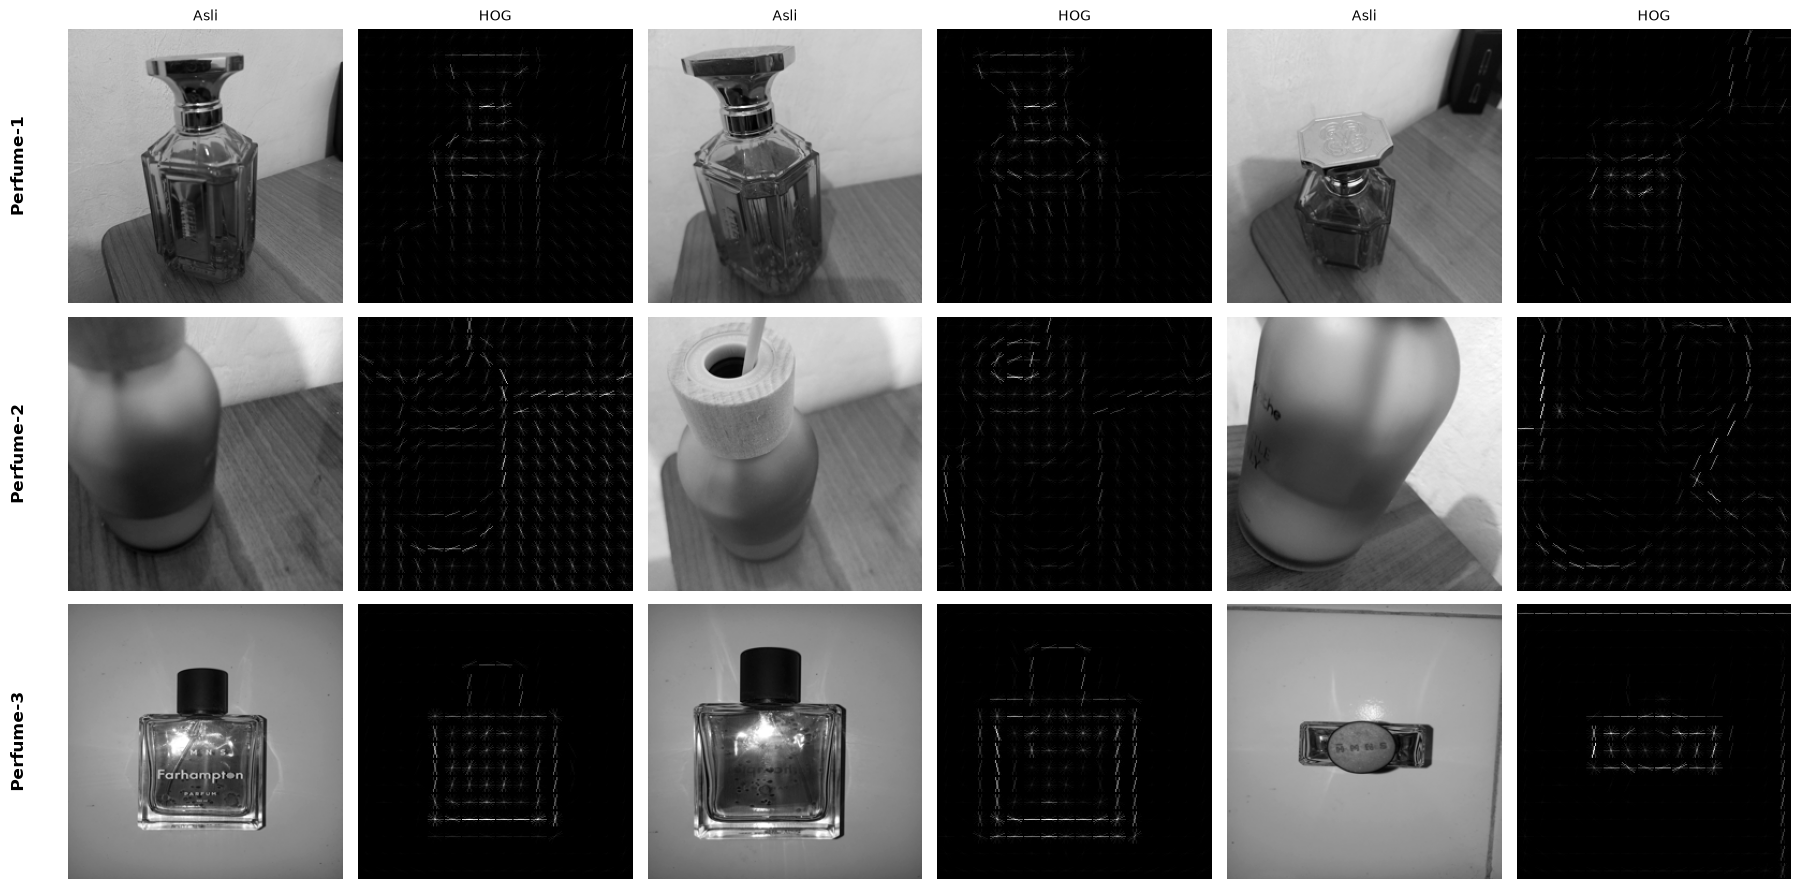

In [10]:
n_per_class = 3

fig, axes = plt.subplots(len(classes), n_per_class * 2, figsize=(3 * n_per_class * 2, 3 * len(classes)))
for row, cls in enumerate(classes):
    files = meta[meta["class"] == cls]["filename"].values[:n_per_class]
    for col, fname in enumerate(files):
        gray_img = preprocess(cls, fname)
        _, hog_img = extract_hog(gray_img, visualize=True)

        ax_orig = axes[row, col * 2]
        ax_orig.imshow(gray_img, cmap="gray")
        ax_orig.axis("off")
        if col == 0:
            ax_orig.text(-0.15, 0.5, cls, transform=ax_orig.transAxes, fontsize=12,
                          fontweight="bold", va="center", ha="right", rotation=90)

        ax_hog = axes[row, col * 2 + 1]
        ax_hog.imshow(hog_img, cmap="gray")
        ax_hog.axis("off")

for ax, title in zip(axes[0], ["Asli", "HOG"] * n_per_class):
    ax.set_title(title, fontsize=10)

plt.tight_layout()
plt.show()

In [11]:
X = []
y = []
for _, r in meta.iterrows():
    gray = preprocess(r["class"], r["filename"])
    feat = extract_hog(gray)
    X.append(feat)
    y.append(r["class"])

X = np.array(X)
y = np.array(y)
X.shape, y.shape

((46, 8100), (46,))

## Dimensionality Reduction: PCA

Satu vektor HOG di sini punya ribuan dimensi, sementara datasetnya cuma 46 citra. Rasio fitur terhadap sampel sebesar itu bikin classifier gampang overfit. PCA saya pakai untuk memampatkan fitur ke jumlah komponen yang jauh lebih kecil sambil mempertahankan sebagian besar variansnya.

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA(n_components=0.95, svd_solver="full", random_state=42)
X_pca = pca_full.fit_transform(X_scaled)
print("Jumlah komponen PCA (mempertahankan 95% varians):", X_pca.shape[1])

Jumlah komponen PCA (mempertahankan 95% varians): 40


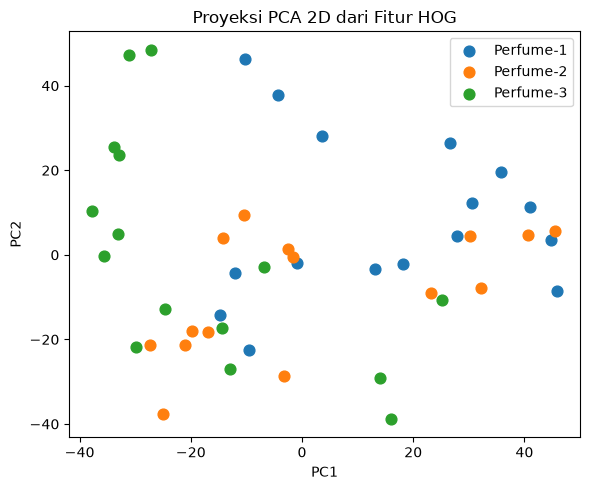

In [13]:
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
for cls in classes:
    mask = y == cls
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=cls, s=60)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Proyeksi PCA 2D dari Fitur HOG")
plt.legend()
plt.tight_layout()
plt.show()

## Support Vector Machine: Konsep Singkat

SVM mencari hyperplane pemisah antar kelas yang memaksimalkan margin, yaitu jarak dari hyperplane itu ke titik data terdekat di tiap kelas. Titik-titik terdekat itu disebut support vector, dan cuma merekalah yang menentukan posisi hyperplane; titik lain di dalam kelas tidak berpengaruh. Untuk data yang tidak terpisah secara linear, SVM memakai kernel trick (misalnya RBF) untuk memproyeksikan data ke ruang berdimensi lebih tinggi, tempat pemisahan linear jadi mungkin.

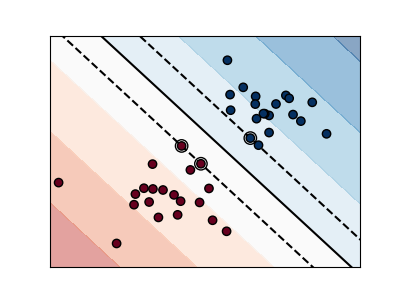
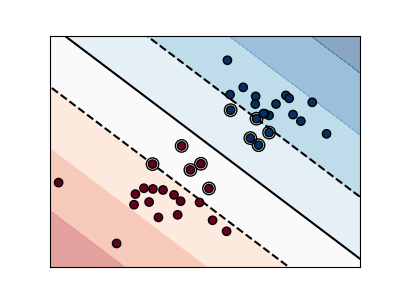

## Training Classifier: SVM

Datasetnya kecil (46 sampel), jadi saya pakai stratified train-test split supaya proporsi tiap kelas tetap terjaga di kedua sisi, lalu grid search dengan cross-validation 3-fold pada data training untuk memilih kernel dan hyperparameter terbaik.

In [14]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.25, stratify=y, random_state=42
)

param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"],
}

grid = GridSearchCV(SVC(random_state=42), param_grid, cv=3, scoring="accuracy")
grid.fit(X_train, y_train)

print("Parameter terbaik:", grid.best_params_)
print("Akurasi cross-validation terbaik:", round(grid.best_score_, 3))

best_svm = grid.best_estimator_

Parameter terbaik: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Akurasi cross-validation terbaik: 0.677


## Evaluasi Model

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = best_svm.predict(X_test)

print("Akurasi pada data test:", round(accuracy_score(y_test, y_pred), 3))
print()
print(classification_report(y_test, y_pred))

Akurasi pada data test: 0.417

              precision    recall  f1-score   support

   Perfume-1       0.60      0.75      0.67         4
   Perfume-2       0.40      0.50      0.44         4
   Perfume-3       0.00      0.00      0.00         4

    accuracy                           0.42        12
   macro avg       0.33      0.42      0.37        12
weighted avg       0.33      0.42      0.37        12



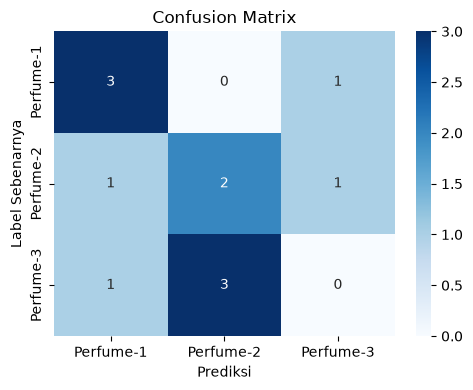

In [16]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=classes)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Prediksi")
plt.ylabel("Label Sebenarnya")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## Diskusi Hasil

Model terbaik dari grid search memakai kernel linear dengan `C=0.1`, dengan akurasi cross-validation 0.677 di data training. Di data test, akurasinya turun ke 0.417: dari 12 citra test, cuma 5 yang terklasifikasi benar. Selisih sebesar itu antara skor cross-validation dan skor test adalah tanda klasik dataset yang kekecilan. Dua belas citra test, empat per kelas, berarti satu citra saja mengubah akurasi sebesar hampir 8 poin persen. Angka akurasi di sini lebih baik dibaca sebagai indikasi kasar, bukan estimasi presisi.

Confusion matrix menunjukkan pola yang jelas. `Perfume-1` paling gampang dikenali (3 dari 4 benar), sementara `Perfume-3` tidak pernah diprediksi benar sama sekali, precision dan recall-nya nol. Tiga dari empat citra `Perfume-3` malah diprediksi sebagai `Perfume-2`. Cek warna rata-rata tiap kelas menjelaskan sebagian dari pola ini: rata-rata RGB `Perfume-2` (122, 118, 105) dan `Perfume-3` (127, 125, 122) berdekatan, jauh lebih dekat dibanding jarak keduanya ke `Perfume-1` (135, 116, 106). Foto diambil dari jarak dekat dengan area latar belakang (meja, tangan) yang cukup luas di setiap frame, jadi warna rata-rata sebenarnya lebih banyak dipengaruhi latar daripada botolnya sendiri. HOG, yang bekerja di gradien intensitas dan bukan warna, ternyata juga tidak cukup menangkap bentuk botol untuk mengompensasi kemiripan itu.

Dua hal kemungkinan menyebabkan performa yang rendah ini. Pertama, jumlah data: 46 citra untuk tiga kelas dengan fitur HOG berdimensi 8100 (sebelum direduksi PCA jadi 40 komponen) memberi rasio sampel terhadap fitur yang sangat kecil. Bahkan setelah PCA, classifier hanya belajar dari sekitar 11 sampai 12 citra training per kelas. Kedua, framing foto: kamera diarahkan dari jarak dekat tanpa kontrol latar belakang, sehingga gradien tepi dari tangan, bayangan, dan tekstur meja ikut masuk ke deskriptor HOG dan mengaburkan sinyal bentuk botol yang sebenarnya ingin ditangkap.

## Eksperimen Tambahan: Augmentasi Data

Bagian ini di luar cakupan wajib tugas. Dataset saya cuma 46 citra, jadi saya penasaran apakah menambah data lewat augmentasi (flip, rotasi, perubahan brightness) bisa membantu classifier belajar lebih baik. Augmentasi saya terapkan hanya pada data training, data test tetap memakai citra asli tanpa augmentasi supaya perbandingannya adil dan tidak ada kebocoran informasi dari test ke training.

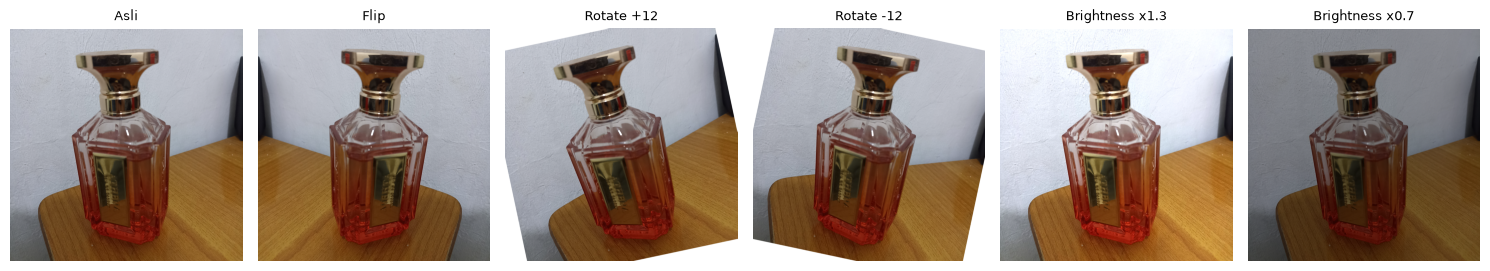

In [17]:
from PIL import ImageOps, ImageEnhance

def load_raw(cls, filename):
    return Image.open(os.path.join(DATASET_DIR, cls, filename)).convert("RGB")

def to_hog_feature(img):
    img = img.resize(IMG_SIZE)
    gray = np.asarray(img.convert("L"), dtype=np.float64) / 255.0
    return hog(gray, **HOG_PARAMS)

def augment_variants(img):
    return [
        img,
        ImageOps.mirror(img),
        img.rotate(12, resample=Image.BILINEAR, fillcolor=(255, 255, 255)),
        img.rotate(-12, resample=Image.BILINEAR, fillcolor=(255, 255, 255)),
        ImageEnhance.Brightness(img).enhance(1.3),
        ImageEnhance.Brightness(img).enhance(0.7),
    ]

# contoh hasil augmentasi pada satu citra
sample_raw = load_raw(meta.iloc[0]["class"], meta.iloc[0]["filename"])
variants = augment_variants(sample_raw)
titles = ["Asli", "Flip", "Rotate +12", "Rotate -12", "Brightness x1.3", "Brightness x0.7"]

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for ax, img, title in zip(axes, variants, titles):
    ax.imshow(img)
    ax.set_title(title, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

Supaya perbandingannya "apples-to-apples", saya pakai pembagian train-test yang sama persis dengan bagian Training Classifier di atas (indeks citra yang sama, `random_state=42`), lalu augmentasi hanya diterapkan ke bagian training-nya.

In [18]:
indices = np.arange(len(meta))
idx_train, idx_test = train_test_split(indices, test_size=0.25, stratify=y, random_state=42)

# training set: citra asli + 5 variasi augmentasi per citra
X_train_aug, y_train_aug = [], []
for i in idx_train:
    r = meta.iloc[i]
    raw = load_raw(r["class"], r["filename"])
    for variant in augment_variants(raw):
        X_train_aug.append(to_hog_feature(variant))
        y_train_aug.append(r["class"])
X_train_aug = np.array(X_train_aug)
y_train_aug = np.array(y_train_aug)

# test set: citra asli saja, tanpa augmentasi
X_test_only, y_test_only = [], []
for i in idx_test:
    r = meta.iloc[i]
    raw = load_raw(r["class"], r["filename"])
    X_test_only.append(to_hog_feature(raw))
    y_test_only.append(r["class"])
X_test_only = np.array(X_test_only)
y_test_only = np.array(y_test_only)

print("Jumlah citra training sebelum augmentasi:", len(idx_train))
print("Jumlah citra training sesudah augmentasi:", X_train_aug.shape[0])
print("Jumlah citra test (tidak diaugmentasi):", X_test_only.shape[0])

Jumlah citra training sebelum augmentasi: 34
Jumlah citra training sesudah augmentasi: 204
Jumlah citra test (tidak diaugmentasi): 12


In [19]:
scaler_aug = StandardScaler().fit(X_train_aug)
X_train_aug_s = scaler_aug.transform(X_train_aug)
X_test_aug_s = scaler_aug.transform(X_test_only)

pca_aug = PCA(n_components=0.95, svd_solver="full", random_state=42).fit(X_train_aug_s)
X_train_aug_p = pca_aug.transform(X_train_aug_s)
X_test_aug_p = pca_aug.transform(X_test_aug_s)
print("Jumlah komponen PCA setelah augmentasi (95% varians):", X_train_aug_p.shape[1])

grid_aug = GridSearchCV(SVC(random_state=42), param_grid, cv=3, scoring="accuracy")
grid_aug.fit(X_train_aug_p, y_train_aug)
print("Parameter terbaik (data augmentasi):", grid_aug.best_params_)
print("Akurasi cross-validation terbaik (data augmentasi):", round(grid_aug.best_score_, 3))

best_svm_aug = grid_aug.best_estimator_
y_pred_aug = best_svm_aug.predict(X_test_aug_p)
print("Akurasi pada data test:", round(accuracy_score(y_test_only, y_pred_aug), 3))
print()
print(classification_report(y_test_only, y_pred_aug))

Jumlah komponen PCA setelah augmentasi (95% varians): 112
Parameter terbaik (data augmentasi): {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Akurasi cross-validation terbaik (data augmentasi): 0.77
Akurasi pada data test: 0.417

              precision    recall  f1-score   support

   Perfume-1       0.40      1.00      0.57         4
   Perfume-2       0.50      0.25      0.33         4
   Perfume-3       0.00      0.00      0.00         4

    accuracy                           0.42        12
   macro avg       0.30      0.42      0.30        12
weighted avg       0.30      0.42      0.30        12



c:\Users\Syauqi Nabil\Lectures\University\Semester 5\Computer Vision\Task\image-classification-2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Syauqi Nabil\Lectures\University\Semester 5\Computer Vision\Task\image-classification-2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Syauqi Nabil\Lectures\University\Semester 5\Computer Vision\Task\image-classification-2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision 

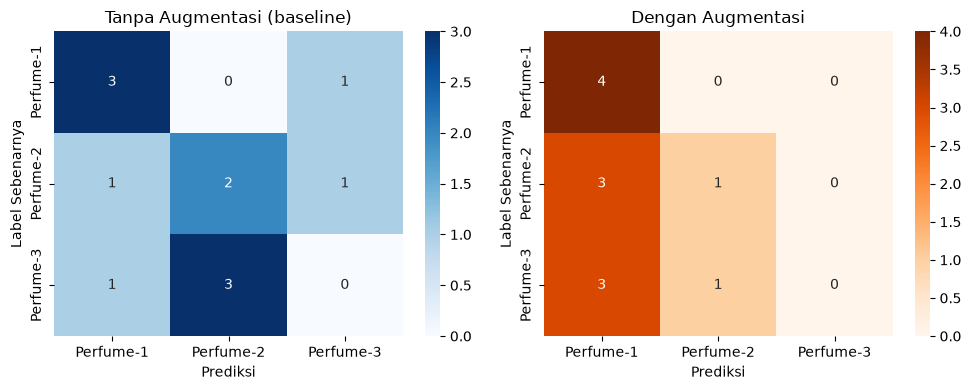

In [20]:
cm_aug = confusion_matrix(y_test_only, y_pred_aug, labels=classes)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title("Tanpa Augmentasi (baseline)")
axes[0].set_xlabel("Prediksi")
axes[0].set_ylabel("Label Sebenarnya")

sns.heatmap(cm_aug, annot=True, fmt="d", cmap="Oranges", xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title("Dengan Augmentasi")
axes[1].set_xlabel("Prediksi")
axes[1].set_ylabel("Label Sebenarnya")

plt.tight_layout()
plt.show()

**Analisis eksperimen augmentasi**

Augmentasi menaikkan jumlah citra training dari 34 jadi 204 (6 kali lipat), dan itu terlihat jelas di skor cross-validation: naik dari 0,677 (baseline) ke 0,770. Tapi begitu diuji ke 12 citra test yang sama persis dan tidak diaugmentasi, akurasinya tetap 0,417, tidak berubah sama sekali dari baseline. Kombinasi hyperparameter terbaik juga bergeser dari kernel linear ke RBF dengan `C=10`, dan jumlah komponen PCA yang dibutuhkan untuk menjelaskan 95% varians melonjak dari 40 ke 112, tanda ruang fiturnya jadi lebih kompleks, bukan lebih sederhana.

Yang lebih menarik adalah pola kesalahannya berubah total. Di baseline, `Perfume-3` paling sering tertukar dengan `Perfume-2` (3 dari 4 salah ke sana). Setelah augmentasi, `Perfume-1` justru diprediksi dengan sempurna (recall 1,00), tapi hampir semua citra `Perfume-2` dan `Perfume-3` (3 dari 4 masing-masing) malah ikut diprediksi sebagai `Perfume-1`. Modelnya tidak menjadi lebih akurat, hanya bias-nya berpindah tempat.

Ada dua dugaan penyebab. Pertama, augmentasi rotasi menambahkan bingkai putih di sudut citra supaya area yang kosong akibat perputaran tetap terisi, dan bingkai putih itu menciptakan tepi tajam buatan yang ikut masuk ke gradien HOG, sinyal palsu yang tidak berhubungan dengan bentuk botol sama sekali. Kedua, dan ini yang lebih mendasar: augmentasi flip dan brightness tetap mempertahankan latar belakang meja kayu dan tangan yang sejak bagian Tantangan Pengumpulan Data sudah saya identifikasi sebagai sumber kontaminasi fitur. Augmentasi menggandakan citra yang bermasalah itu enam kali lipat, bukan mengganti dengan citra yang lebih bersih, jadi classifier belajar lebih banyak dari sinyal yang salah, bukan sinyal yang benar.

Kesimpulannya, dugaan bahwa masalah utama ada di jumlah data ternyata tidak sepenuhnya tepat. Menambah kuantitas data lewat augmentasi sederhana tidak cukup kalau kualitas datanya sendiri masih terkontaminasi latar belakang dan sebagian foto blur (khususnya `Perfume-2`). Augmentasi baru akan efektif kalau diterapkan pada data yang sudah bersih dari awal; di sini augmentasi hanya melipatgandakan masalah yang sudah ada dalam bentuk variasi yang berbeda-beda.

## Eksperimen Tambahan: Fitur Warna (Color Histogram) sebagai Pengganti HOG

Bagian ini di luar cakupan wajib tugas. HOG sama sekali buta warna, ia cuma menangkap gradien intensitas. Dari analisis warna rata-rata di awal notebook, saturasi tiap kelas kelihatan cukup berbeda, jadi saya penasaran apakah fitur berbasis warna murni bisa menangkap sinyal yang terlewat oleh HOG. Saya ganti HOG dengan histogram warna HSV (16 bin per channel Hue, Saturation, Value, jadi 48 dimensi per citra, jauh lebih ringkas dari 8100 dimensi HOG), sisa pipeline (scaler, PCA, SVM, train-test split) tetap sama seperti eksperimen baseline supaya perbandingannya adil.

Panjang vektor fitur color histogram per citra: 48


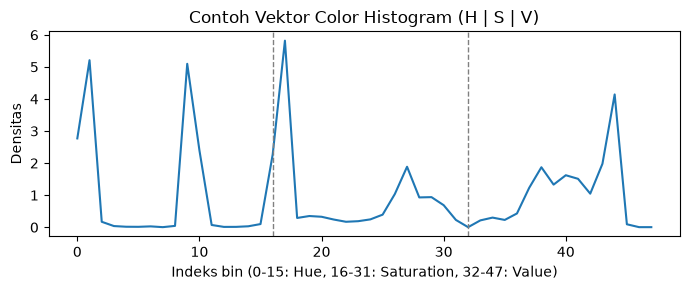

In [21]:
from matplotlib.colors import rgb_to_hsv

def color_histogram_feature(cls, filename, bins=16):
    img = load_image(cls, filename, size=IMG_SIZE)
    arr = np.asarray(img, dtype=np.float64) / 255.0
    hsv = rgb_to_hsv(arr)
    channel_hists = []
    for ch in range(3):
        hist, _ = np.histogram(hsv[:, :, ch], bins=bins, range=(0, 1), density=True)
        channel_hists.append(hist)
    return np.concatenate(channel_hists)

# contoh histogram warna pada satu citra
sample_hist = color_histogram_feature(meta.iloc[0]["class"], meta.iloc[0]["filename"])
print("Panjang vektor fitur color histogram per citra:", sample_hist.shape[0])

plt.figure(figsize=(7, 3))
plt.plot(sample_hist)
plt.axvline(16, color="gray", linestyle="--", linewidth=1)
plt.axvline(32, color="gray", linestyle="--", linewidth=1)
plt.title("Contoh Vektor Color Histogram (H | S | V)")
plt.xlabel("Indeks bin (0-15: Hue, 16-31: Saturation, 32-47: Value)")
plt.ylabel("Densitas")
plt.tight_layout()
plt.show()

In [22]:
X_train_color = np.array([
    color_histogram_feature(meta.iloc[i]["class"], meta.iloc[i]["filename"]) for i in idx_train
])
y_train_color = np.array([meta.iloc[i]["class"] for i in idx_train])

X_test_color = np.array([
    color_histogram_feature(meta.iloc[i]["class"], meta.iloc[i]["filename"]) for i in idx_test
])
y_test_color = np.array([meta.iloc[i]["class"] for i in idx_test])

scaler_color = StandardScaler().fit(X_train_color)
X_train_color_s = scaler_color.transform(X_train_color)
X_test_color_s = scaler_color.transform(X_test_color)

pca_color = PCA(n_components=0.95, svd_solver="full", random_state=42).fit(X_train_color_s)
X_train_color_p = pca_color.transform(X_train_color_s)
X_test_color_p = pca_color.transform(X_test_color_s)
print("Jumlah komponen PCA (color histogram, 95% varians):", X_train_color_p.shape[1])

grid_color = GridSearchCV(SVC(random_state=42), param_grid, cv=3, scoring="accuracy")
grid_color.fit(X_train_color_p, y_train_color)
print("Parameter terbaik (color histogram):", grid_color.best_params_)
print("Akurasi cross-validation terbaik (color histogram):", round(grid_color.best_score_, 3))

best_svm_color = grid_color.best_estimator_
y_pred_color = best_svm_color.predict(X_test_color_p)
print("Akurasi pada data test:", round(accuracy_score(y_test_color, y_pred_color), 3))
print()
print(classification_report(y_test_color, y_pred_color))

Jumlah komponen PCA (color histogram, 95% varians): 18
Parameter terbaik (color histogram): {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Akurasi cross-validation terbaik (color histogram): 0.914
Akurasi pada data test: 0.833

              precision    recall  f1-score   support

   Perfume-1       1.00      1.00      1.00         4
   Perfume-2       0.67      1.00      0.80         4
   Perfume-3       1.00      0.50      0.67         4

    accuracy                           0.83        12
   macro avg       0.89      0.83      0.82        12
weighted avg       0.89      0.83      0.82        12



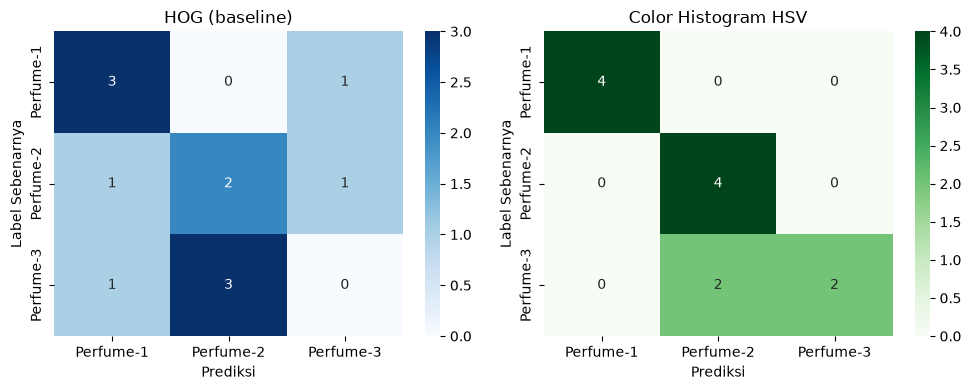

In [23]:
cm_color = confusion_matrix(y_test_color, y_pred_color, labels=classes)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title("HOG (baseline)")
axes[0].set_xlabel("Prediksi")
axes[0].set_ylabel("Label Sebenarnya")

sns.heatmap(cm_color, annot=True, fmt="d", cmap="Greens", xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title("Color Histogram HSV")
axes[1].set_xlabel("Prediksi")
axes[1].set_ylabel("Label Sebenarnya")

plt.tight_layout()
plt.show()

**Analisis eksperimen fitur warna**

Hasilnya jauh melampaui dugaan saya. Color histogram HSV memberi akurasi cross-validation 0,914 dan akurasi test 0,833, dibanding HOG yang cuma 0,677 dan 0,417. Padahal vektor fiturnya jauh lebih ringkas, cuma 48 dimensi berbanding 8100 dimensi HOG, dan PCA cuma perlu 18 komponen untuk menjelaskan 95% variansnya (HOG butuh 40). Fitur yang lebih kecil tapi jauh lebih informatif untuk kasus ini.

Confusion matrix-nya juga jauh lebih bersih: `Perfume-1` dan `Perfume-2` diprediksi sempurna (recall 1,00 untuk keduanya), cuma `Perfume-3` yang masih separuh salah, 2 dari 4 citranya terprediksi sebagai `Perfume-2`. Ini konsisten dengan analisis warna di awal notebook: saturasi rata-rata `Perfume-2` (sekitar 0,25) dan `Perfume-3` (sekitar 0,13) memang berdekatan dibanding `Perfume-1` (sekitar 0,32), jadi kesalahan yang tersisa pun searah dengan yang sudah saya duga sejak eksperimen warna pertama.

Kenapa color histogram bisa jauh mengungguli HOG, padahal latar belakang meja dan tangan ikut masuk ke tiap foto? Kemungkinan karena latar belakangnya (kayu coklat, dinding putih) warnanya relatif netral dan konsisten di ketiga kelas, jadi menjadi semacam "baseline" yang sama, sementara warna botol sendiri (merah muda-oranye pekat, hijau pucat, hampir netral gelap) tetap menonjol sebagai puncak-puncak berbeda di histogram. HOG sebaliknya memperlakukan gradien tepi meja, bayangan, dan tekstur latar dengan bobot yang sama seperti gradien tepi botol, jadi sinyal bentuknya justru tenggelam di tengah noise gradien latar yang jauh lebih banyak jumlahnya (8100 dimensi, sebagian besar dari luar area botol).

Ini bikin saya menyadari bahwa asumsi awal saya soal HOG, PCA, dan SVM sebagai pilihan "yang seharusnya paling masuk akal" untuk kasus ini kurang tepat. Warna dominan tiap botol, yang justru jadi alasan awal saya memilih tema ini, ternyata memang sinyal paling kuat untuk membedakan ketiganya, jauh lebih kuat daripada bentuk siluetnya.